In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00010
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  263.1529811622469
RUN  2 , total integrated cost =  78.01320626386688
RUN  3 , total integrated cost =  43.899040731195775
RUN  4 , total integrated cost =  27.32738716263753
RUN  5 , total integrated cost =  26.762689632016997
RUN  6 , total integrated cost =  25.231729613478826
RUN  7 , total integrated cost =  25.148672602908313
RUN  8 , total integrated cost =  25.14151745374832
RUN  9 , total integrated cost =  25.12829990466908
RUN  10 , total integrated cost =  25.072729407819867
RUN  11 , total integrated cost =  25.061764605024884
RUN  12 , total integrated cost =  25.05839616182616
RUN  13 , total integrated cost =  24.606805041077525
RUN  14 , total integrated cost =  24.598740447473045
RUN  15 , total integrated cost =  24.38803366655274
RU

ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  19.99915190897727
Control only changes marginally.
RUN  106 , total integrated cost =  19.999151908977137
Improved over  106  iterations in  13.186755772680044  seconds by  99.84975961832274  percent.
Problem in initial value trasfer:  Vmean_exc -56.672384368497184 -56.6723833384975
weight =  6656.000130165411
set cost params:  1.0 0.0 6656.000130165411
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13184.266354385529
Gradient descend method:  None
RUN  1 , total integrated cost =  12402.540910372594
RUN  2 , total integrated cost =  12397.894685862315
RUN  3 , total integrated cost =  12383.550644601006
RUN  4 , total integrated cost =  12382.1922948873
RUN  5 , total integrated cost =  12381.815240451055
RUN  6 , total integrated cost =  12378.824457983817
RUN  7 , total integrated cost =  12366.606963624874
RUN  8 , total integrated cost =  12365.273226415153
RUN  9 , total integrated cost =  12365.067910214137
RUN  10 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  12315.046771341407
Improved over  28  iterations in  0.6401154585182667  seconds by  6.592855147795092  percent.
Problem in initial value trasfer:  Vmean_exc -56.67197764137056 -56.671986680656566
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  164.76671073439513
RUN  2 , total integrated cost =  70.38666112141361
RUN  3 , total integrated cost =  36.07192387649666
RUN  4 , total integrated cost =  27.272156807830633
RUN  5 , total integrated cost =  25.991370134572538
RUN  6 , total integrated cost =  25.425965625543547
RUN  7 , total integrated cost =  25.31550262247237
RUN  8 , total integrated cost =  25.15758366237424
RUN  9 , total integrated cost =  25.126547583644726
RUN  10 , total integrated cost =  23.95729020611477
RUN  1

...

RUN  18 , total integrated cost =  20277.528743048395
RUN  19 , total integrated cost =  20277.52874304839
RUN  20 , total integrated cost =  20277.52874304839
Control only changes marginally.
RUN  20 , total integrated cost =  20277.52874304839
Improved over  20  iterations in  0.49241393245756626  seconds by  5.185489011541151  percent.
Problem in initial value trasfer:  Vmean_exc -56.698361124889395 -56.698362074085686
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21069.13235378212
Gradient descend method:  None
RUN  1 , total integrated cost =  776.6584737536275
RUN  2 , total integrated cost =  255.30284035821765
RUN  3 , total integrated cost =  255.1643465354706
RUN  4 , total integrated cost =  158.26119699817355
RUN  5 , total integrated cost =  58.336733879754384
RUN  6 , total integrated cost =  52.96118215411865
RUN  7 , total integrated cost =  50.75021211214742
RUN  

ERROR:root:Problem in initial value trasfer


RUN  70 , total integrated cost =  37.80518442873828
Control only changes marginally.
RUN  75 , total integrated cost =  37.80518442873807
Improved over  75  iterations in  1.634040491655469  seconds by  99.82056601195563  percent.
Problem in initial value trasfer:  Vmean_exc -56.697371478066636 -56.69737099050717
weight =  5573.080166689032
set cost params:  1.0 0.0 5573.080166689032
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20925.79277191509
Gradient descend method:  None
RUN  1 , total integrated cost =  20043.77765958302
RUN  2 , total integrated cost =  20042.72987980017
RUN  3 , total integrated cost =  20024.470729876582
RUN  4 , total integrated cost =  20018.58837867593
RUN  5 , total integrated cost =  20018.417356729788
RUN  6 , total integrated cost =  20018.37912070858
RUN  7 , total integrated cost =  20018.36381504874
RUN  8 , total integrated cost =  20018.354335001924
RUN  9 , total integrated cost =  20018.341688436733
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  19997.254878080283
Control only changes marginally.
RUN  34 , total integrated cost =  19997.2548780801
Improved over  34  iterations in  0.7356310244649649  seconds by  4.437288966567607  percent.
Problem in initial value trasfer:  Vmean_exc -56.697337941596096 -56.69733862820082
-------  44 0.47500000000000014 0.5750000000000003
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019489862996
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019489862996
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019489862996
Improved over  1  iterations in  0.05850476771593094  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019489862996
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019489862996
Control only changes marginally.
RUN  1

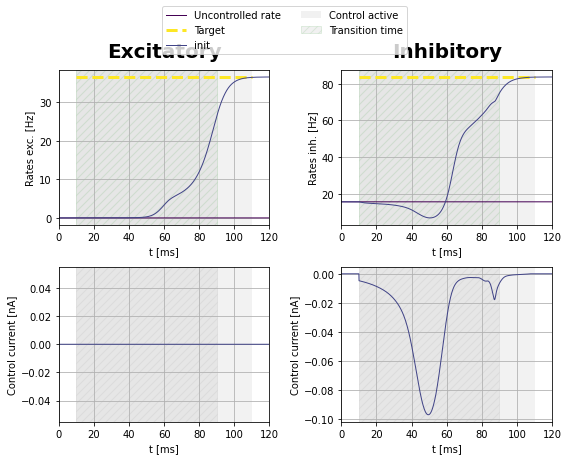

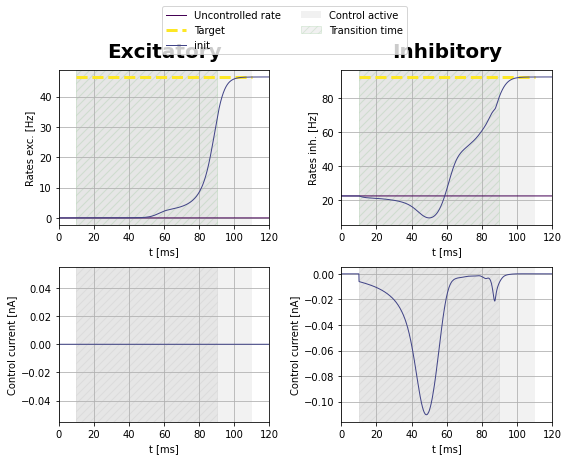

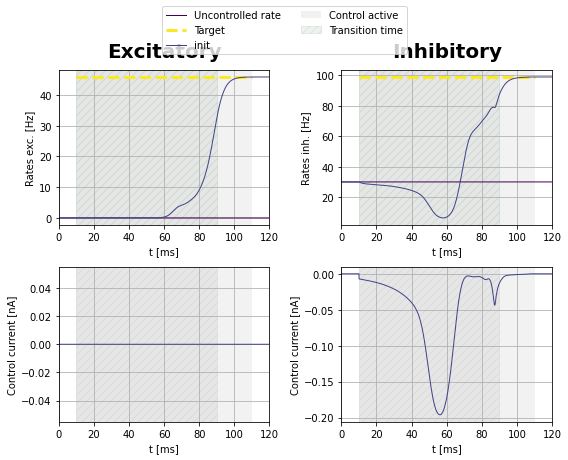

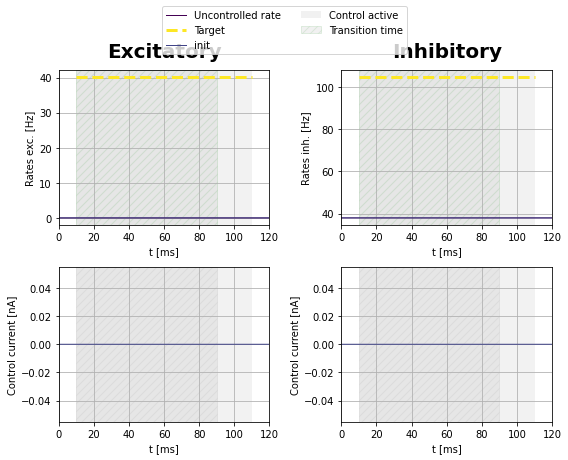

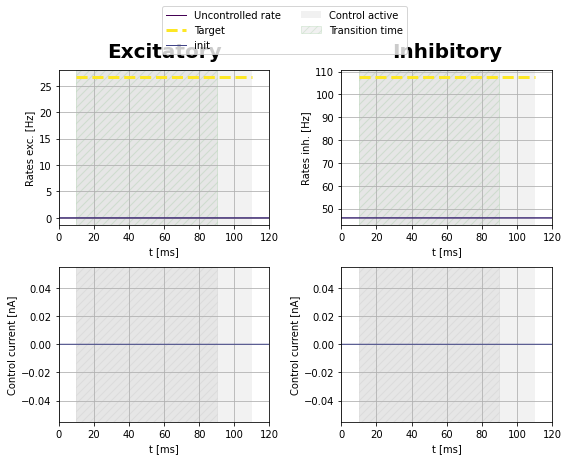

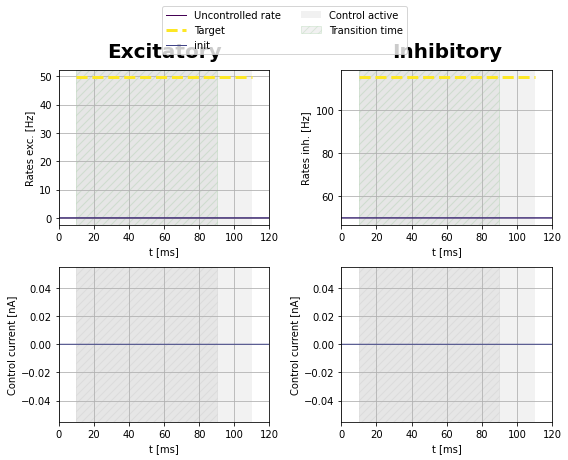

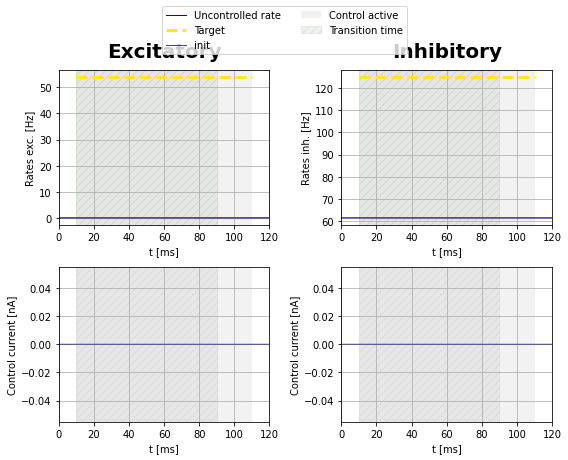

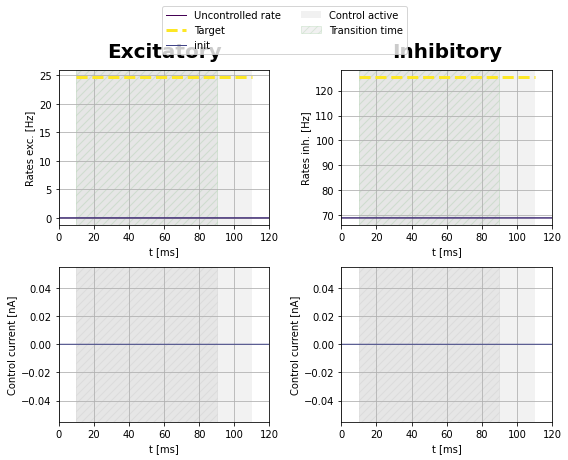

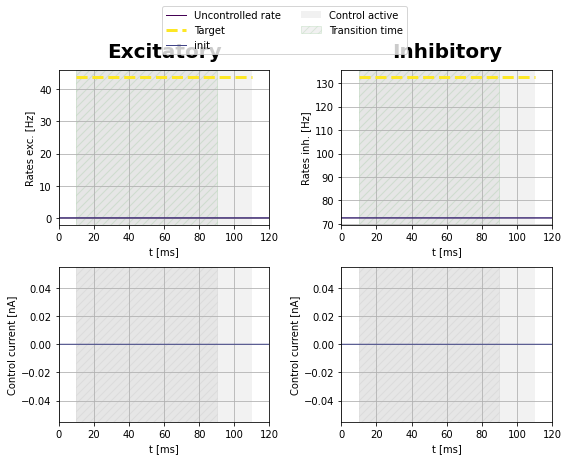

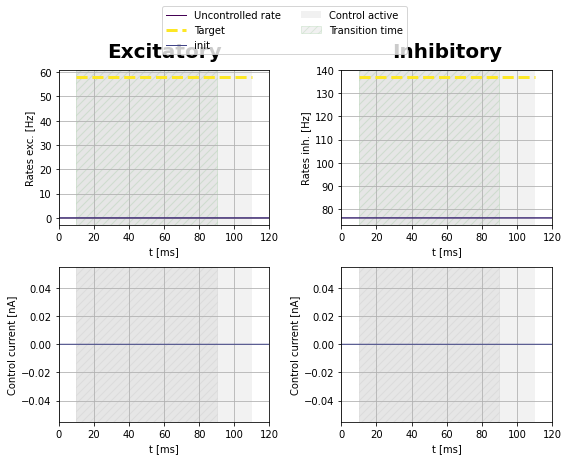

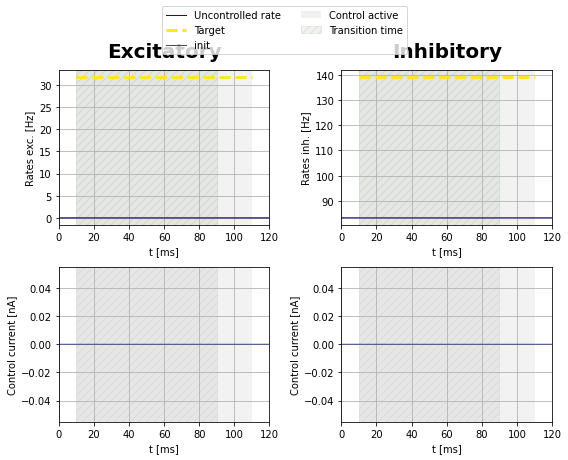

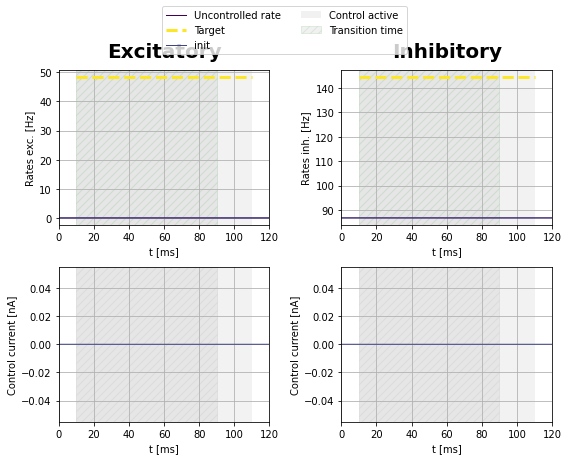

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  91.35719357430114
Control only changes marginally.
RUN  48 , total integrated cost =  91.35719357427699
Improved over  48  iterations in  1.0326653514057398  seconds by  98.71561498113651  percent.
Problem in initial value trasfer:  Vmean_exc -56.631611980011215 -56.631611842443434
-------  66 0.5250000000000001 0.6500000000000004
[0, 11, 22, 33] []
closest index  33
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24777.220470441072
Gradient descend method:  None
RUN  1 , total integrated cost =  24743.40062391907
RUN  2 , total integrated cost =  110.1035399942157
RUN  3 , total integrated cost =  97.73591184557122
RUN  4 , total integrated cost =  96.00690594497934
RUN  5 , total integrated cost =  92.47013061561523
RUN  6 , total integrated cost =  89.50311974740653
RUN  7 , total integrated cost =  77.95200779463562
RUN  8 , total integrated cost =  63.839805586157595
RUN

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  62.210219658035086
Control only changes marginally.
RUN  47 , total integrated cost =  62.210219642664285
Improved over  47  iterations in  1.0417119730263948  seconds by  99.7489217173618  percent.
Problem in initial value trasfer:  Vmean_exc -56.702097384977876 -56.70209722288479
weight =  3977.164792266827
set cost params:  1.0 0.0 3977.164792266827
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24631.160066010314
Gradient descend method:  None
RUN  1 , total integrated cost =  24123.083913481234
RUN  2 , total integrated cost =  24123.064816876635
RUN  3 , total integrated cost =  24123.061608679407
RUN  4 , total integrated cost =  24123.061044273436
RUN  5 , total integrated cost =  24123.06099598548
RUN  6 , total integrated cost =  24123.06096520666
RUN  7 , total integrated cost =  24123.060961240022
RUN  8 , total integrated cost =  24123.060959686853
RUN  9 , total integrated cost =  24123.060959546427
RUN  10 , tot

...

RUN  30 , total integrated cost =  23388.75124158737
Control only changes marginally.
RUN  38 , total integrated cost =  23388.75123782168
Improved over  38  iterations in  0.8420732915401459  seconds by  0.14160594864023324  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054203619942 -56.70054213924256
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0, 11, 22, 33, 77]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
[0, 11, 22, 33, 77] [33]
closest index  22
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16156.581744865454
Gradient descend method:  None
RUN  1 , total

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  58.426153297219635
Control only changes marginally.
RUN  45 , total integrated cost =  58.426153297219386
Improved over  45  iterations in  0.9400379974395037  seconds by  99.63837552881019  percent.
Problem in initial value trasfer:  Vmean_exc -56.68405804745239 -56.684058102988644
weight =  2761.951382931621
set cost params:  1.0 0.0 2761.951382931621
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16085.858661837083
Gradient descend method:  None
RUN  1 , total integrated cost =  15839.476705178593
RUN  2 , total integrated cost =  15839.217799705886
RUN  3 , total integrated cost =  15839.20099231436
RUN  4 , total integrated cost =  15839.19579825289
RUN  5 , total integrated cost =  15839.193884909944
RUN  6 , total integrated cost =  15839.192702790688
RUN  7 , total integrated cost =  15839.19146162212
RUN  8 , total integrated cost =  15839.190449129947
RUN  9 , total integrated cost =  15839.189135207762
RUN  10 , tot

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  15823.154364950005
RUN  14 , total integrated cost =  15812.67934413401
RUN  15 , total integrated cost =  15812.679344134003
RUN  16 , total integrated cost =  15812.679344133989
RUN  17 , total integrated cost =  15812.679344133989
Control only changes marginally.
RUN  17 , total integrated cost =  15812.679344133989
Improved over  17  iterations in  0.45434537529945374  seconds by  1.6982576028172929  percent.
Problem in initial value trasfer:  Vmean_exc -56.68396169547025 -56.6839643860877
-------  55 0.4250000000000001 0.6250000000000003
found solution for  55
-------  66 0.5250000000000001 0.6500000000000004
found solution for  66
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
found solution for  88
-------  99 0.4250000000000001 0.7750000000000005
found solution for  99
-------  110 0.5000000000000002 0.8000000000000005
found solution for  110
-------  121 0.5750000000000002 0.825000000000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  7193.525515746851
set cost params:  1.0 0.0 7193.525515746851
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13298.543055002496
Gradient descend method:  None
RUN  1 , total integrated cost =  13298.334761729264
RUN  2 , total integrated cost =  13298.322458004102
RUN  3 , total integrated cost =  13298.3211084497
RUN  4 , total integrated cost =  13298.320883152533
RUN  5 , total integrated cost =  13298.320838845082
RUN  6 , total integrated cost =  13298.320832243086
RUN  7 , total integrated cost =  13298.32082270166


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  13298.32081363423
RUN  9 , total integrated cost =  13298.320811238897
RUN  10 , total integrated cost =  13298.32081068694
RUN  11 , total integrated cost =  13298.320810569958
RUN  12 , total integrated cost =  13298.320810567428
RUN  13 , total integrated cost =  13298.320810567424
RUN  14 , total integrated cost =  13298.320810567422
RUN  15 , total integrated cost =  13298.320810567422
Control only changes marginally.
RUN  15 , total integrated cost =  13298.320810567422
Improved over  15  iterations in  0.39093627594411373  seconds by  0.0016711938605169507  percent.
Problem in initial value trasfer:  Vmean_exc -56.671957002000596 -56.67196654544073
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  10918.586411319719
set cost params:  1.0 0.0 10918.586411319719
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21551.420426085428
Gradient descend method:  None
RUN  1 , total integrated cost =  21551.3

ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  21551.30648392263
RUN  9 , total integrated cost =  21551.306477471157
RUN  10 , total integrated cost =  21551.306470389605
RUN  11 , total integrated cost =  21551.306468722327
RUN  12 , total integrated cost =  21551.30646868915
RUN  13 , total integrated cost =  21551.306468687893
RUN  14 , total integrated cost =  21551.30646868785
RUN  15 , total integrated cost =  21551.30646868785
Control only changes marginally.
RUN  15 , total integrated cost =  21551.30646868785
Improved over  15  iterations in  0.36902493983507156  seconds by  0.0005287697763094457  percent.
Problem in initial value trasfer:  Vmean_exc -56.69835996911237 -56.69836095902135
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5870.804123420894
set cost params:  1.0 0.0 5870.804123420894
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21056.4799056734
Gradient descend method:  None
RUN  1 , total integrated cost =  21056.383921453

...

RUN  0 , total integrated cost =  13309.587121803537
Gradient descend method:  None
RUN  1 , total integrated cost =  13309.587121803535
RUN  2 , total integrated cost =  13309.587121803535
Control only changes marginally.
RUN  2 , total integrated cost =  13309.587121803535
Improved over  2  iterations in  0.13679024763405323  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.67195673139364 -56.67196628144298
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5873.384044646682
set cost params:  1.0 0.0 5873.384044646682
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21065.545736841363
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21065.545736841363
Control only changes marginally.
RUN  1 , total integrated cost =  21065.545736841363
Improved over  1  iterations in  0.07430492714047432  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69733675822467 -56.697337485440144
-------  44 0.47500000000000014 0.5750000000000003
no convergence
weight =  2817.776312247247
set cost params:  1.0 0.0 2817.776312247247
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16131.294658310673
Gradient descend method:  None
RUN  1 , total integrated cost =  16131.294658310673
Control only changes marginally.
RUN  1 , total integrated cost =  16131.294658310673
Improved over  1  iterations in  0.07198936678469181  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.683960706441844 -56.683963424025194
-------  55 0.4250000000000001 0.6250000000000003
no convergence
weight =  792.5190184944976
set cost params:  1.0 0.0 792.5190184944

ERROR:root:Problem in initial value trasfer



-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  7199.688058358669
set cost params:  1.0 0.0 7199.688058358669
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13309.587136904483
Gradient descend method:  None
RUN  1 , total integrated cost =  13309.587136904483
Control only changes marginally.
RUN  1 , total integrated cost =  13309.587136904483
Improved over  1  iterations in  0.07716700807213783  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67195673139364 -56.67196628144298
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  88 0.55000000000000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  165.55050023667366
Gradient descend method:  None
RUN  1 , total integrated cost =  20.01196041702601
RUN  2 , total integrated cost =  19.76444385608243
RUN  3 , total integrated cost =  19.743048975858578
RUN  4 , total integrated cost =  19.71377341497509
RUN  5 , total integrated cost =  19.697698459875134
RUN  6 , total integrated cost =  19.688651705536614
RUN  7 , total integrated cost =  19.68498174481285
RUN  8 , total integrated cost =  19.639348079788064
RUN  9 , total integrated cost =  19.619406427634647
RUN  10 , total integrated cost =  19.61345614532722
RUN  11 , total integrated cost =  19.610193244269276
RUN  12 , total integrated cost =  19.60672558387683
RUN  13 , total integrated cost =  19.58059470437123
RUN  14 , total integrated cost =  19.5673000813703
RUN  15 , total integrated cost =  19.567166465108155
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  125 , total integrated cost =  19.43810579333853
Improved over  125  iterations in  7.536760102957487  seconds by  88.25850374021854  percent.
Problem in initial value trasfer:  Vmean_exc -56.67236439954876 -56.67236393724727
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  193.9140540233873
Gradient descend method:  HS
RUN  1 , total integrated cost =  192.33417418753058
RUN  2 , total integrated cost =  192.20080853282644
RUN  3 , total integrated cost =  192.19885895671231
RUN  4 , total integrated cost =  192.19885895671223
RUN  5 , total integrated cost =  192.1988588378818
RUN  6 , total integrated cost =  192.19830266804047
RUN  7 , total integrated cost =  192.19830260333347
RUN  8 , total integrated cost =  192.19830260333325
RUN  9 , total integrated cost =  192.19830260333322
RUN  10 , total integrated cost =  192.19830260333316


ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  192.19830260333316
Control only changes marginally.
RUN  11 , total integrated cost =  192.19830260333316
Improved over  11  iterations in  1.267960213124752  seconds by  0.8847999329884715  percent.
Problem in initial value trasfer:  Vmean_exc -56.6723592654994 -56.67235892116864
weight =  6924.886228250235
set cost params:  1.0 0.0 6924.886228250235
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13193.465779643502
Gradient descend method:  None
RUN  1 , total integrated cost =  12755.764104256985
RUN  2 , total integrated cost =  12748.500515780861
RUN  3 , total integrated cost =  12739.327263318575
RUN  4 , total integrated cost =  12732.786797889321
RUN  5 , total integrated cost =  12732.575948059139
RUN  6 , total integrated cost =  12732.46660455097
RUN  7 , total integrated cost =  12732.433790282736
RUN  8 , total integrated cost =  12732.416523964117
RUN  9 , total integrated cost =  12732.411097782962
RUN  10 , tot

...

RUN  10 , total integrated cost =  10091.106486230074
Control only changes marginally.
RUN  10 , total integrated cost =  10091.106486230074
Improved over  10  iterations in  0.8486890718340874  seconds by  0.07428669490813888  percent.
Problem in initial value trasfer:  Vmean_exc -56.65212100683626 -56.65212417722585
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  121.43734098296243
Gradient descend method:  None
RUN  1 , total integrated cost =  115.29753538779711
RUN  2 , total integrated cost =  115.27560944089984
RUN  3 , total integrated cost =  115.25631931471872
RUN  4 , total integrated cost =  115.24841724504718
RUN  5 , total integrated cost =  115.24545639689215
RUN  6 , total integrated cost =  115.24541018307376
RUN  7 , total integrated cost =  115.24536851167933
RUN  8 , total integrated cost =  115.2450408513006
RUN  9 , total integrated cost =  115.24503916021352


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  136 , total integrated cost =  115.2431089671243
Improved over  136  iterations in  10.44634254090488  seconds by  5.100763871886144  percent.
Problem in initial value trasfer:  Vmean_exc -56.700544499147036 -56.700544532180736
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1152.2493564449014
Gradient descend method:  HS
RUN  1 , total integrated cost =  1151.892874027593
RUN  2 , total integrated cost =  1145.574785869573
RUN  3 , total integrated cost =  1142.6768901464632
RUN  4 , total integrated cost =  1142.668656496403
RUN  5 , total integrated cost =  1142.6654282206705
RUN  6 , total integrated cost =  1142.0093675155224
RUN  7 , total integrated cost =  1141.9332364304548
RUN  8 , total integrated cost =  1141.9271215821448
RUN  9 , total integrated cost =  1141.641138193675
RUN  10 , total integrated cost =  1141.6157588119395
RUN  11 , total integrated cost =  1141.6

ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  23397.467183665904
RUN  5 , total integrated cost =  23397.467183665904
Control only changes marginally.
RUN  5 , total integrated cost =  23397.467183665904
Improved over  5  iterations in  0.453104130923748  seconds by  0.06262838493273648  percent.
Problem in initial value trasfer:  Vmean_exc -56.70054218615466 -56.70054228045785


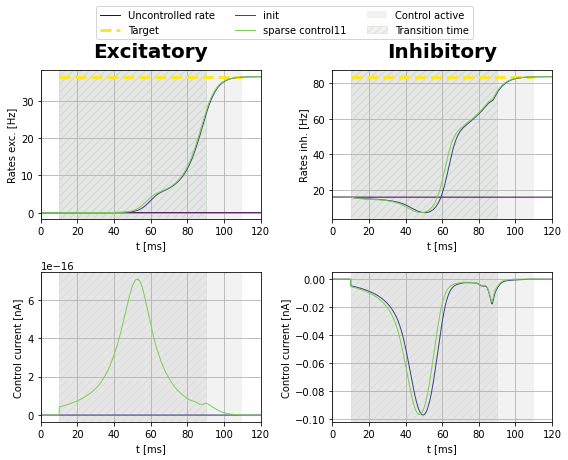

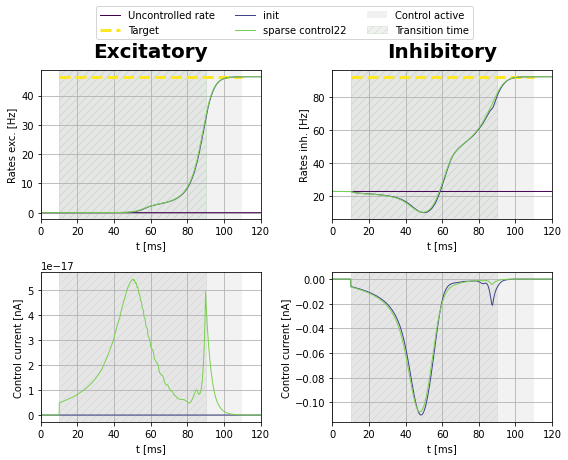

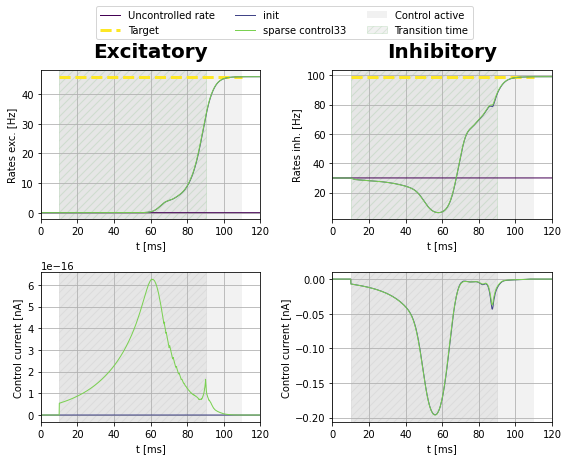

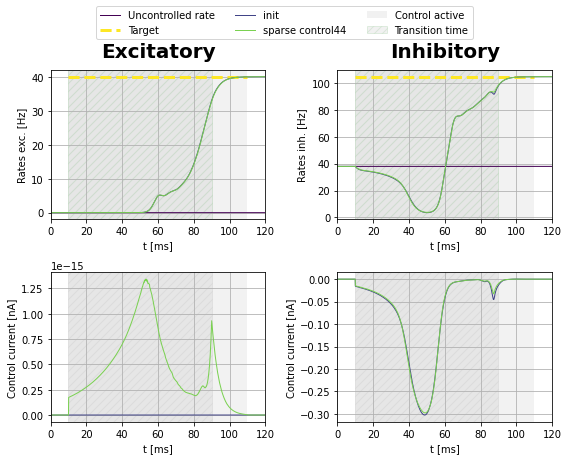

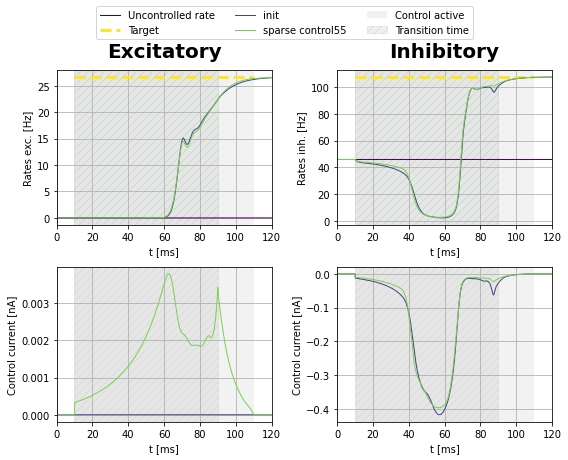

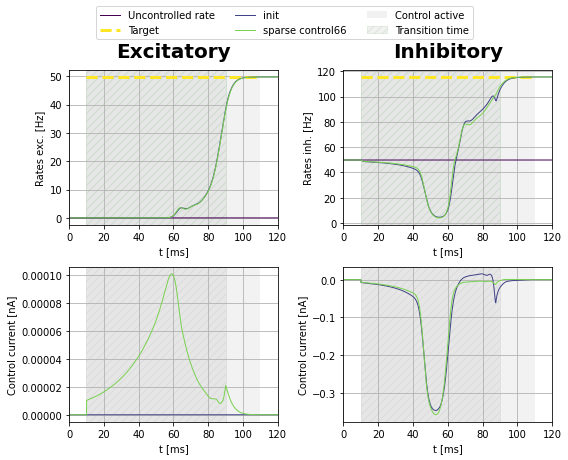

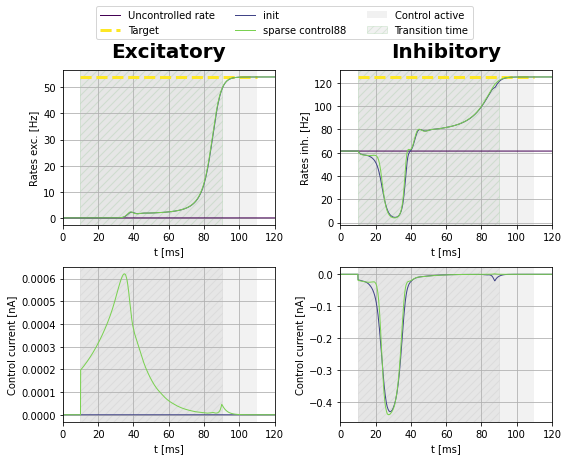

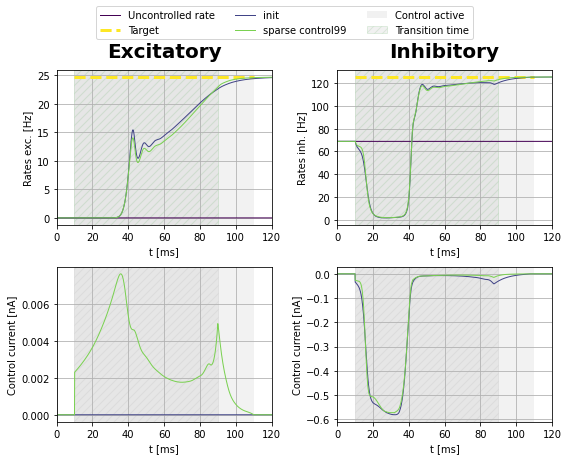

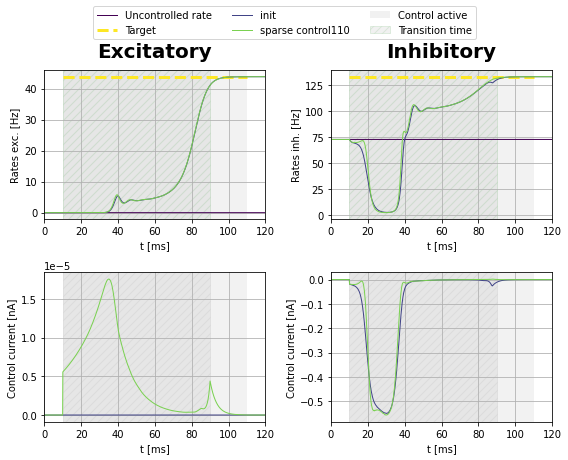

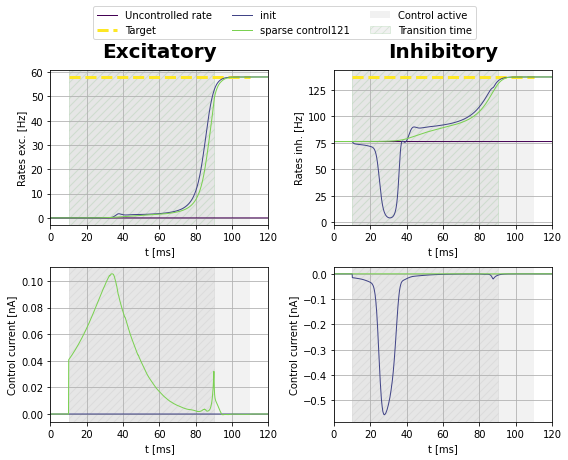

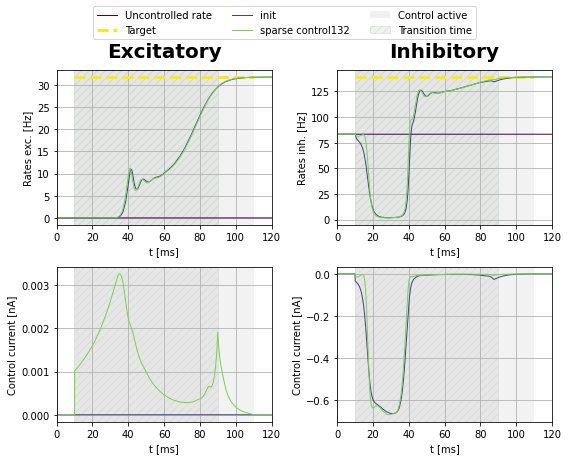

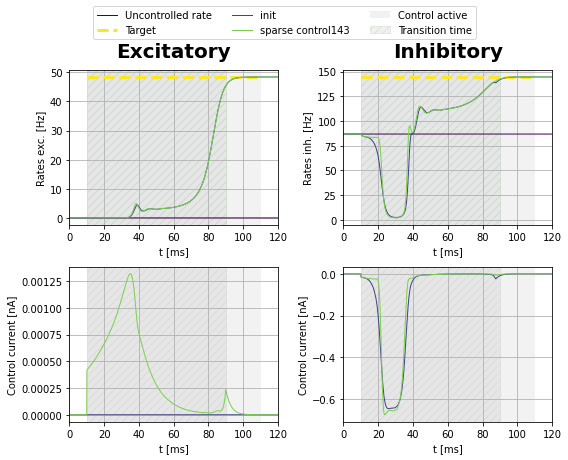

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  7251.894065606291
set cost params:  1.0 0.0 7251.894065606291
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13303.924579678582
Gradient descend method:  None
RUN  1 , total integrated cost =  13303.850328064682
RUN  2 , total integrated cost =  13303.848630878738
RUN  3 , total integrated cost =  13303.84852619412
RUN  4 , total integrated cost =  13303.848524378394
RUN  5 , total integrated cost =  13303.848524107261
RUN  6 , total integrated cost =  13303.848524065888
RUN  7 , total integrated cost =  13303.84852405997
RUN  8 , total integrated cost =  13303.848524059094
RUN  9 , total integrated cost =  13303.848524058962
RUN  10 , total integrated

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  13303.848524058925
RUN  15 , total integrated cost =  13303.848524058925
Control only changes marginally.
RUN  15 , total integrated cost =  13303.848524058925
Improved over  15  iterations in  1.6428889632225037  seconds by  0.0005716780728874937  percent.
Problem in initial value trasfer:  Vmean_exc -56.67197953283693 -56.67198869127643
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  10989.09966215577
set cost params:  1.0 0.0 10989.09966215577
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21555.024880177865
Gradient descend method:  None
RUN  1 , total integrated cost =  21554.938669168376
RUN  2 , total integrated cost =  21554.93841753407
RUN  3 , total integrated cost =  21554.938417357
RUN  4 , total integrated cost =  21554.938417356578
RUN  5 , total integrated cost =  21554.93841735657
RUN  6 , total integrated cost =  21554.938417356567


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  21554.938417356567
Control only changes marginally.
RUN  7 , total integrated cost =  21554.938417356567
Improved over  7  iterations in  1.0051494762301445  seconds by  0.00040112605658748635  percent.
Problem in initial value trasfer:  Vmean_exc -56.698361558117725 -56.69836248645391
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5879.77364951569
set cost params:  1.0 0.0 5879.77364951569
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21059.75838339026
Gradient descend method:  None
RUN  1 , total integrated cost =  21059.709765228316
RUN  2 , total integrated cost =  21059.706490972098
RUN  3 , total integrated cost =  21059.706150067443
RUN  4 , total integrated cost =  21059.706129061156
RUN  5 , total integrated cost =  21059.70612457727
RUN  6 , total integrated cost =  21059.70612353268
RUN  7 , total integrated cost =  21059.706123309323
RUN  8 , total integrated cost =  21059.7061232568
RUN

...

RUN  1 , total integrated cost =  21563.216106188953
Control only changes marginally.
RUN  1 , total integrated cost =  21563.216106188953
Improved over  1  iterations in  0.20372614450752735  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69836154980309 -56.69836247843264
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5881.4190519794765
set cost params:  1.0 0.0 5881.4190519794765
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21065.550638204808
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21065.550638204808
Control only changes marginally.
RUN  1 , total integrated cost =  21065.550638204808
Improved over  1  iterations in  0.205194603651762  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69733595967818 -56.697336733783736
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  14007.685352228553
set cost params:  1.0 0.0 14007.685352228553
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33630.05729599819
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33630.05729599819
Control only changes marginally.
RUN  1 , total integrated cost =  33630.05729599819
Improved over  1  iterations in  0.20841996185481548  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703448120267915 -56.703446866499725
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 4
[[True, True], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [False, False], [True, False], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  127.24958671836302
Gradient descend method:  None
RUN  1 , total integrated cost =  2.0148288031295043
RUN  2 , total integrated cost =  2.0111483746712766
RUN  3 , total integrated cost =  2.007928189380267
RUN  4 , total integrated cost =  2.0032634137510645
RUN  5 , total integrated cost =  2.0025951051396302
RUN  6 , total integrated cost =  1.9878069628780157
RUN  7 , total integrated cost =  1.9827919910027354
RUN  8 , total integrated cost =  1.9827429574798912
RUN  9 , total integrated cost =  1.9827344126692923
RUN  10 , total integrated cost =  1.9827262603675502
RUN  11 , total integrated cost =  1.9826769731689693
RUN  12 , total integrated cost =  1.9812645523889878
RUN  13 , total integrated cost =  1.9807385363158605
RUN  14 , total integrated cost =  1.980726471294809
RUN  15 , total integrated cost =  1.980723286463115

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  45 , total integrated cost =  1.9676419477507898
Improved over  45  iterations in  0.9925878345966339  seconds by  98.453714468947  percent.
Problem in initial value trasfer:  Vmean_exc -56.67235259374253 -56.672352658102234
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  183.58827623205568
Gradient descend method:  None
RUN  1 , total integrated cost =  2.1546753099981677
RUN  2 , total integrated cost =  2.1502946314698232
RUN  3 , total integrated cost =  2.1382547146015844
RUN  4 , total integrated cost =  2.132656617003875
RUN  5 , total integrated cost =  2.13068931009536
RUN  6 , total integrated cost =  2.1265878545766776
RUN  7 , total integrated cost =  2.1255217751873037
RUN  8 , total integrated cost =  2.1231598401016383
RUN  9 , total integrated cost =  2.1193841440521677
RUN  10 , total integrated cost =  2.1190393036427513
RUN  11

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  2.08759231247235
Control only changes marginally.
RUN  42 , total integrated cost =  2.0875923124723497
Improved over  42  iterations in  0.9215322863310575  seconds by  98.86289454026267  percent.
Problem in initial value trasfer:  Vmean_exc -56.698388152110596 -56.698388141202145
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  178.19888013864005
Gradient descend method:  None
RUN  1 , total integrated cost =  3.838487610792809
RUN  2 , total integrated cost =  3.8369740078799515
RUN  3 , total integrated cost =  3.8354752274272212
RUN  4 , total integrated cost =  3.8312394168713118
RUN  5 , total integrated cost =  3.830320083778053
RUN  6 , total integrated cost =  3.829812860191454
RUN  7 , total integrated cost =  3.825089922991472
RUN  8 , total integrated cost =  3.823159515485917
RUN  9 , total integrated cost =  3.8229956781545567
RUN  10 

...

RUN  9 , total integrated cost =  13.194736028650217
RUN  10 , total integrated cost =  13.194736028650214
RUN  11 , total integrated cost =  13.194736028650208
RUN  12 , total integrated cost =  13.194736028650208
Control only changes marginally.
RUN  12 , total integrated cost =  13.194736028650208
Improved over  12  iterations in  0.29746441170573235  seconds by  25.366913163245172  percent.
Problem in initial value trasfer:  Vmean_exc -56.62573309622834 -56.62573020218324
-------  110 0.5000000000000002 0.8000000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.72463178632833
Gradient descend method:  None
RUN  1 , total integrated cost =  10.40109476404339
RUN  2 , total integrated cost =  10.401090191917898
RUN  3 , total integrated cost =  10.401063504893818
RUN  4 , total integrated cost =  10.398313163646717
RUN  5 , total integrated cost =  10.396729742841831
RUN  6 , total integrated cost =  10.396729372696447


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  2.605822966900698
Improved over  22  iterations in  0.5051201973110437  seconds by  95.29555042673697  percent.
Problem in initial value trasfer:  Vmean_exc -56.70344692533929 -56.70344573407138
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20.640536598829243
Gradient descend method:  None
RUN  1 , total integrated cost =  14.419295921298692
RUN  2 , total integrated cost =  14.419231631977857
RUN  3 , total integrated cost =  14.419226889244491
RUN  4 , total integrated cost =  14.419225395732433
RUN  5 , total integrated cost =  14.419224498242862
RUN  6 , total integrated cost =  14.419223440385432
RUN  7 , total integrated cost =  14.419221156490881
RUN  8 , total integrated cost =  14.419206756415027


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  14.403064143471736
RUN  10 , total integrated cost =  14.40007338603322
RUN  11 , total integrated cost =  14.400073369357628
RUN  12 , total integrated cost =  14.400073369216463
RUN  13 , total integrated cost =  14.400073369215892
RUN  14 , total integrated cost =  14.400073369215862
RUN  15 , total integrated cost =  14.40007336921586
RUN  16 , total integrated cost =  14.40007336921586
Control only changes marginally.
RUN  16 , total integrated cost =  14.40007336921586
Improved over  16  iterations in  0.3932039812207222  seconds by  30.234016444937524  percent.
Problem in initial value trasfer:  Vmean_exc -56.65230504687921 -56.65230578010511
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17.889898288477916
Gradient descend method:  None
RUN  1 , total integrated cost =  11.435480201889655
RUN  2 , total integrated cost =  11.435271125287072

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.9676419477507898
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1.9676419477507898
Control only changes marginally.
RUN  1 , total integrated cost =  1.9676419477507898
Improved over  1  iterations in  0.0638638399541378  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67235259374253 -56.672352658102234
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.0875923124723497
Gradient descend method:  None
RUN  1 , total integrated cost =  2.0875923124723497
Control only changes marginally.
RUN  1 , total integrated cost =  2.0875923124723497
Improved over  1  iterations in  0.06204327195882797  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.698388152110596 -56.698388141202145
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.79738845

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5.8546534390829885
Control only changes marginally.
RUN  1 , total integrated cost =  5.8546534390829885
Improved over  1  iterations in  0.062222935259342194  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68406227447303 -56.68406225045355
-------  55 0.4250000000000001 0.6250000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.085199958764342
Gradient descend method:  None
RUN  1 , total integrated cost =  9.085199958764342
Control only changes marginally.
RUN  1 , total integrated cost =  9.085199958764342
Improved over  1  iterations in  0.06234888359904289  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.63154576981181 -56.63154672189978
-------  66 0.5250000000000001 0.6500000000000004
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.236393921082

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6.646119261163902
Control only changes marginally.
RUN  1 , total integrated cost =  6.646119261163902
Improved over  1  iterations in  0.06348631158471107  seconds by  0.0  percent.
-------  99 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.194736028650208
Gradient descend method:  None
RUN  1 , total integrated cost =  13.194736028650208
Control only changes marginally.
RUN  1 , total integrated cost =  13.194736028650208
Improved over  1  iterations in  0.06543701142072678  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62573309622834 -56.62573020218324
-------  110 0.5000000000000002 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.396729310844936
Gradient descend method:  None
RUN  1 , total integrated cost =  10.396729310

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.605822966900698
Control only changes marginally.
RUN  1 , total integrated cost =  2.605822966900698
Improved over  1  iterations in  0.06212128885090351  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70344692533929 -56.70344573407138
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.40007336921586
Gradient descend method:  None
RUN  1 , total integrated cost =  14.40007336921586
Control only changes marginally.
RUN  1 , total integrated cost =  14.40007336921586
Improved over  1  iterations in  0.062291691079735756  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65230504687921 -56.65230578010511
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11.43527052092

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
